In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Verify GPU + install dependencies
# Runtime → Change Runtime Type → T4 GPU → Save
# ─────────────────────────────────────────────────────────────────────────────
import torch

print("=" * 55)
print("  Environment Check")
print("=" * 55)
print(f"  PyTorch     : {torch.__version__}")
if torch.cuda.is_available():
    print(f"  GPU         : ✅ {torch.cuda.get_device_name(0)}")
    print(f"  VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"  CUDA        : {torch.version.cuda}")
else:
    print("  GPU         : ❌ Not found!")
    print("  → Runtime → Change Runtime Type → T4 GPU")
print("=" * 55)

# Install required packages
print("\n📦 Installing packages...")
!pip install -q transformers datasets torch scikit-learn \
             pandas numpy matplotlib seaborn accelerate \
             huggingface_hub

print("✅ All packages installed!")

# Verify transformers version
import transformers
print(f"  Transformers: {transformers.__version__}")

  Environment Check
  PyTorch     : 2.10.0+cu128
  GPU         : ✅ Tesla T4
  VRAM        : 15.6 GB
  CUDA        : 12.8

📦 Installing packages...
✅ All packages installed!
  Transformers: 5.0.0


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Import all libraries
# ─────────────────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn.functional as F

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

# ── Constants ─────────────────────────────────────────────────────────────────
MODEL_CHECKPOINT = "distilbert-base-uncased"   # pretrained base model
SAVE_DIR         = "./sentiment-model"         # local save path
MAX_LENGTH       = 128                         # max token length (tweets are short)
NUM_LABELS       = 3                           # Negative / Neutral / Positive
SEED             = 42

LABEL_NAMES  = ["Negative", "Neutral", "Positive"]
LABEL_EMOJIS = {"Negative": "😠", "Neutral": "😐", "Positive": "😊"}
LABEL_COLORS = {"Negative": "#e74c3c", "Neutral": "#f39c12", "Positive": "#27ae60"}

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries loaded | Device: {DEVICE}")

✅ Libraries loaded | Device: cuda


In [3]:
# CELL 3: Load tweet_eval sentiment dataset
# 3 classes: 0=Negative, 1=Neutral, 2=Positive
# Twitter-domain data — matches real-world social media sentiment
print("📥 Loading tweet_eval/sentiment dataset...")

dataset = load_dataset("tweet_eval", "sentiment")

print(f"\n✅ Dataset loaded!")
print(f"\n  Splits:")
for split, ds in dataset.items():
    print(f"    {split:<12} {len(ds):>6} samples")

# Label mapping
label_feature = dataset["train"].features["label"]
print(f"\n  Label names: {label_feature.names}")
print(f"  Mapped to  : {LABEL_NAMES}")

# Sample tweets
print("\n  Sample tweets:")
print("  " + "─"*55)
for i in [0, 5, 10]:
    row = dataset["train"][i]
    print(f"  [{LABEL_NAMES[row['label']]}] {row['text'][:70]}...")

📥 Loading tweet_eval/sentiment dataset...


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]


✅ Dataset loaded!

  Splits:
    train         45615 samples
    test          12284 samples
    validation     2000 samples

  Label names: ['negative', 'neutral', 'positive']
  Mapped to  : ['Negative', 'Neutral', 'Positive']

  Sample tweets:
  ───────────────────────────────────────────────────────
  [Positive] "QT @user In the original draft of the 7th book, Remus Lupin survived ...
  [Positive] @user LIT MY MUM 'Kerry the louboutins I wonder how many Willam owns!!...
  [Neutral] @user Well said on HMW. Can you now address why Texans fans file out o...


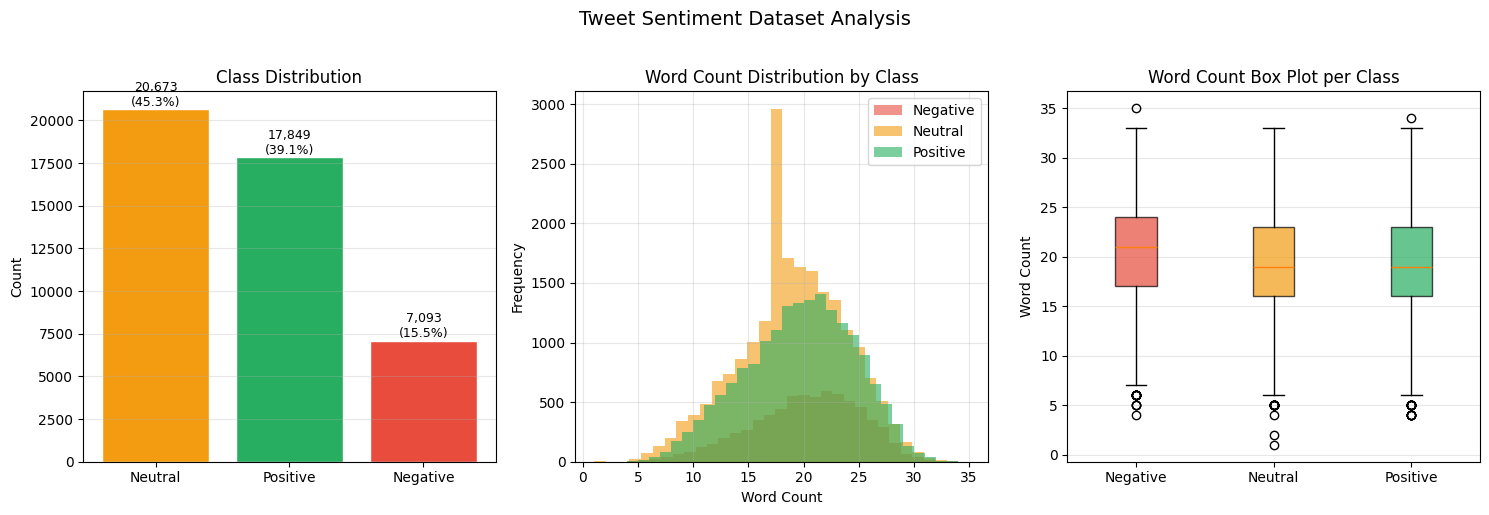

  Total training samples : 45,615
  Avg words per tweet    : 19.2
  Max words              : 35
  Tweets > 128 tokens    : will be truncated


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Explore dataset — class distribution + text length analysis
# ─────────────────────────────────────────────────────────────────────────────
df_train = pd.DataFrame(dataset["train"])
df_train["label_name"] = df_train["label"].map(
    {0: "Negative", 1: "Neutral", 2: "Positive"}
)
df_train["text_length"] = df_train["text"].apply(len)
df_train["word_count"]  = df_train["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Tweet Sentiment Dataset Analysis", fontsize=14, y=1.02)

# ── Class distribution
counts = df_train["label_name"].value_counts()
colors = [LABEL_COLORS[l] for l in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white")
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, (label, cnt) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, cnt + 200, f"{cnt:,}\n({cnt/len(df_train)*100:.1f}%)",
                 ha="center", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# ── Word count per class
for label, color in LABEL_COLORS.items():
    subset = df_train[df_train["label_name"] == label]["word_count"]
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[1].set_title("Word Count Distribution by Class")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Text length by class ───────────────────────────────────────────────────
data_by_class = [
    df_train[df_train["label_name"] == lbl]["word_count"].values
    for lbl in LABEL_NAMES
]
bp = axes[2].boxplot(data_by_class, labels=LABEL_NAMES, patch_artist=True)
for patch, color in zip(bp["boxes"], LABEL_COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title("Word Count Box Plot per Class")
axes[2].set_ylabel("Word Count")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("dataset_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"  Total training samples : {len(df_train):,}")
print(f"  Avg words per tweet    : {df_train['word_count'].mean():.1f}")
print(f"  Max words              : {df_train['word_count'].max()}")
print(f"  Tweets > 128 tokens    : will be truncated")

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: Load tokenizer + tokenize all splits
# ─────────────────────────────────────────────────────────────────────────────
print(f"📥 Loading tokenizer: {MODEL_CHECKPOINT}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# ── Tokenization function ─────────────────────────────────────────────────
def tokenize_function(examples):
    """
    Convert raw text to token IDs + attention masks.
    - padding="max_length"  : pad all sequences to MAX_LENGTH
    - truncation=True       : cut sequences longer than MAX_LENGTH
    """
    return tokenizer(
        examples["text"],
        padding    = "max_length",
        truncation = True,
        max_length = MAX_LENGTH,
    )

# ── Apply to all splits ───────────────────────────────────────────────────
print("⚙️  Tokenizing dataset...")
tokenized = dataset.map(tokenize_function, batched=True,
                        desc="Tokenizing")

# Set format for PyTorch
tokenized.set_format(
    type    = "torch",
    columns = ["input_ids", "attention_mask", "label"],
)

print(f"\n✅ Tokenization complete!")
print(f"  Input shape  : {tokenized['train'][0]['input_ids'].shape}")
print(f"  Max length   : {MAX_LENGTH} tokens")
print(f"\n  Example token IDs:")
sample = tokenized["train"][0]
print(f"    Text    : {dataset['train'][0]['text'][:60]}...")
print(f"    Tokens  : {tokenizer.convert_ids_to_tokens(sample['input_ids'][:10])}")
print(f"    IDs     : {sample['input_ids'][:10].tolist()}")

📥 Loading tokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

⚙️  Tokenizing dataset...


Tokenizing:   0%|          | 0/45615 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/12284 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/2000 [00:00<?, ? examples/s]


✅ Tokenization complete!
  Input shape  : torch.Size([128])
  Max length   : 128 tokens

  Example token IDs:
    Text    : "QT @user In the original draft of the 7th book, Remus Lupin...
    Tokens  : ['[CLS]', '"', 'q', '##t', '@', 'user', 'in', 'the', 'original', 'draft']
    IDs     : [101, 1000, 1053, 2102, 1030, 5310, 1999, 1996, 2434, 4433]


In [6]:
# CELL 6: Load DistilBERT with custom 3-class classification head
#
# Architecture:
#   DistilBERT base (6 transformer layers, 66M params)
#       ↓
#   [CLS] token embedding (768-dim)
#       ↓
#   Linear(768 → 3)  ← NEW layer we train
#       ↓
#   Softmax → Negative / Neutral / Positive
print(f"📥 Loading model: {MODEL_CHECKPOINT}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels = NUM_LABELS,
    id2label   = {0: "Negative", 1: "Neutral", 2: "Positive"},
    label2id   = {"Negative": 0, "Neutral": 1, "Positive": 2},
)
model.to(DEVICE)

# ── Model statistics ──────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_params= sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n✅ Model loaded on {DEVICE}")
print(f"   Total parameters    : {total_params/1e6:.1f}M")
print(f"   Trainable parameters: {trainable_params/1e6:.1f}M")
print(f"   Classification head : {model.classifier}")
print(f"   Labels              : {model.config.id2label}")

📥 Loading model: distilbert-base-uncased


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded on cuda
   Total parameters    : 67.0M
   Trainable parameters: 67.0M
   Classification head : Linear(in_features=768, out_features=3, bias=True)
   Labels              : {0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7: Define evaluation metrics
# Called after each epoch by the Trainer
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    """
    Compute accuracy, macro F1, and weighted F1 from model predictions.
    Called automatically after each eval_strategy step.
    """
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)

    acc    = accuracy_score(labels, predictions)
    f1_w   = f1_score(labels, predictions, average="weighted", zero_division=0)
    f1_m   = f1_score(labels, predictions, average="macro",    zero_division=0)
    prec   = precision_score(labels, predictions, average="weighted", zero_division=0)
    rec    = recall_score(labels, predictions,    average="weighted", zero_division=0)

    return {
        "accuracy"  : round(acc,  4),
        "f1_weighted": round(f1_w, 4),
        "f1_macro"  : round(f1_m, 4),
        "precision" : round(prec, 4),
        "recall"    : round(rec,  4),
    }

print("✅ compute_metrics defined")

✅ compute_metrics defined


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8: Prepare training datasets + TrainingArguments
# ─────────────────────────────────────────────────────────────────────────────

# ── Sample datasets ───────────────────────────────────────────────────────
TRAIN_SIZE = 5000
EVAL_SIZE  = 1000
TEST_SIZE  = 2000

train_dataset = (
    tokenized["train"]
    .shuffle(seed=SEED)
    .select(range(TRAIN_SIZE))
)
eval_dataset  = (
    tokenized["validation"]
    .shuffle(seed=SEED)
    .select(range(min(EVAL_SIZE, len(tokenized["validation"]))))
)
test_dataset  = (
    tokenized["test"]
    .shuffle(seed=SEED)
    .select(range(min(TEST_SIZE, len(tokenized["test"]))))
)

print(f"  Train  : {len(train_dataset):,} samples")
print(f"  Eval   : {len(eval_dataset):,} samples")
print(f"  Test   : {len(test_dataset):,} samples")

# ── TrainingArguments ─────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = "./results",
    num_train_epochs            = 6,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,          # 10% warmup steps
    eval_strategy               = "epoch",      # evaluate after each epoch
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    greater_is_better           = True,
    fp16                        = torch.cuda.is_available(),  # mixed precision on GPU
    logging_steps               = 50,
    logging_dir                 = "./logs",
    report_to                   = "none",       # disable wandb
    seed                        = SEED,
)

# ── Trainer ───────────────────────────────────────────────────────────────
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = eval_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"\n✅ Trainer ready!")
print(f"   Epochs       : {training_args.num_train_epochs}")
print(f"   Batch size   : {training_args.per_device_train_batch_size}")
print(f"   Learning rate: {training_args.learning_rate}")
print(f"   Mixed FP16   : {training_args.fp16}")
steps_per_epoch = len(train_dataset) // training_args.per_device_train_batch_size
print(f"   Steps/epoch  : {steps_per_epoch}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  Train  : 5,000 samples
  Eval   : 1,000 samples
  Test   : 2,000 samples

✅ Trainer ready!
   Epochs       : 6
   Batch size   : 32
   Learning rate: 2e-05
   Mixed FP16   : True
   Steps/epoch  : 156


🚀 Starting fine-tuning...
   Training on cuda
   Dataset: tweet_eval/sentiment (3-class)
   5000 train samples × 6 epochs



Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision,Recall
1,0.219802,1.090832,0.666000,0.662000,0.641900,0.668800,0.666000
2,0.245297,1.006358,0.660000,0.662100,0.636200,0.665600,0.660000
3,0.162814,1.224752,0.677000,0.676700,0.649800,0.684200,0.677000
4,0.097625,1.352759,0.694000,0.691900,0.660500,0.695400,0.694000
5,0.076348,1.441211,0.686000,0.686500,0.660900,0.690800,0.686000
6,0.057281,1.468514,0.689000,0.688600,0.663100,0.689700,0.689000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  ✅ Training Complete!
  Total time    : 2.4 minutes
  Train samples : 5000
  Final loss    : 0.1469
  Steps/second  : 6.47


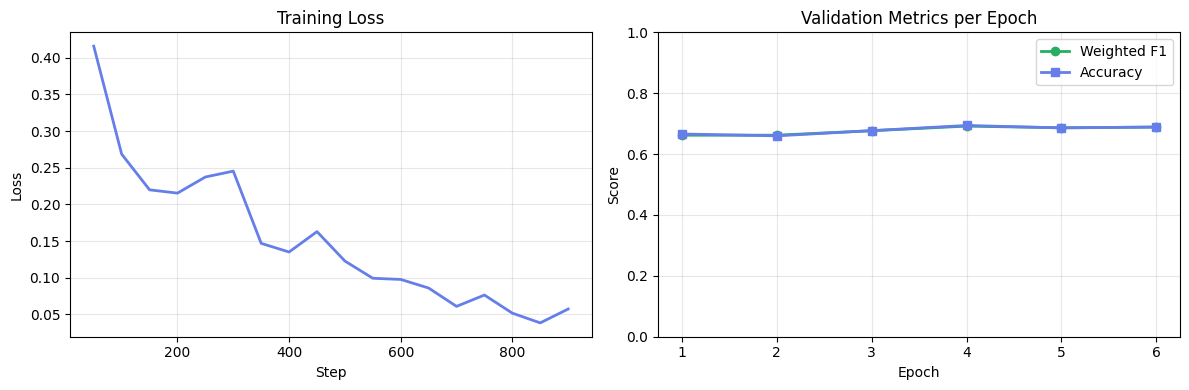

  📊 Training curves saved → training_curves.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9: Fine-tune DistilBERT
# Expected time on T4 GPU: ~5-8 minutes total (3 epochs)
# ─────────────────────────────────────────────────────────────────────────────
import time

print("🚀 Starting fine-tuning...")
print(f"   Training on {DEVICE}")
print(f"   Dataset: tweet_eval/sentiment (3-class)")
print(f"   {TRAIN_SIZE} train samples × {training_args.num_train_epochs} epochs\n")

t_start = time.time()
train_result = trainer.train()
elapsed = time.time() - t_start

# ── Training summary ──────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  ✅ Training Complete!")
print(f"{'='*55}")
print(f"  Total time    : {elapsed/60:.1f} minutes")
print(f"  Train samples : {train_result.metrics.get('train_samples', TRAIN_SIZE)}")
print(f"  Final loss    : {train_result.metrics.get('train_loss', 0):.4f}")
print(f"  Steps/second  : {train_result.metrics.get('train_steps_per_second', 0):.2f}")

# ── Plot training loss curve ───────────────────────────────────────────────
log_history = trainer.state.log_history
train_loss  = [(x["step"], x["loss"])
               for x in log_history if "loss" in x and "eval_loss" not in x]
eval_metrics= [(x["epoch"], x["eval_f1_weighted"], x["eval_accuracy"])
               for x in log_history if "eval_f1_weighted" in x]

if train_loss and eval_metrics:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    steps, losses = zip(*train_loss)
    ax1.plot(steps, losses, color="#667eea", linewidth=2)
    ax1.set_title("Training Loss", fontsize=12)
    ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)

    epochs, f1s, accs = zip(*eval_metrics)
    ax2.plot(epochs, f1s,  "o-", color="#27ae60", label="Weighted F1",  linewidth=2)
    ax2.plot(epochs, accs, "s-", color="#667eea", label="Accuracy",     linewidth=2)
    ax2.set_title("Validation Metrics per Epoch", fontsize=12)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
    ax2.legend(); ax2.grid(alpha=0.3)
    ax2.set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("  📊 Training curves saved → training_curves.png")

📊 Evaluating on test set...



  TEST SET RESULTS  (2000 samples)
  Accuracy          : 64.50%
  F1-Score (weighted): 64.27%
  F1-Score (macro)   : 63.61%
  Precision          : 65.43%
  Recall             : 64.50%

  Per-class Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.52      0.60       638
     Neutral       0.64      0.71      0.67       972
    Positive       0.58      0.69      0.63       390

    accuracy                           0.65      2000
   macro avg       0.65      0.64      0.64      2000
weighted avg       0.65      0.65      0.64      2000



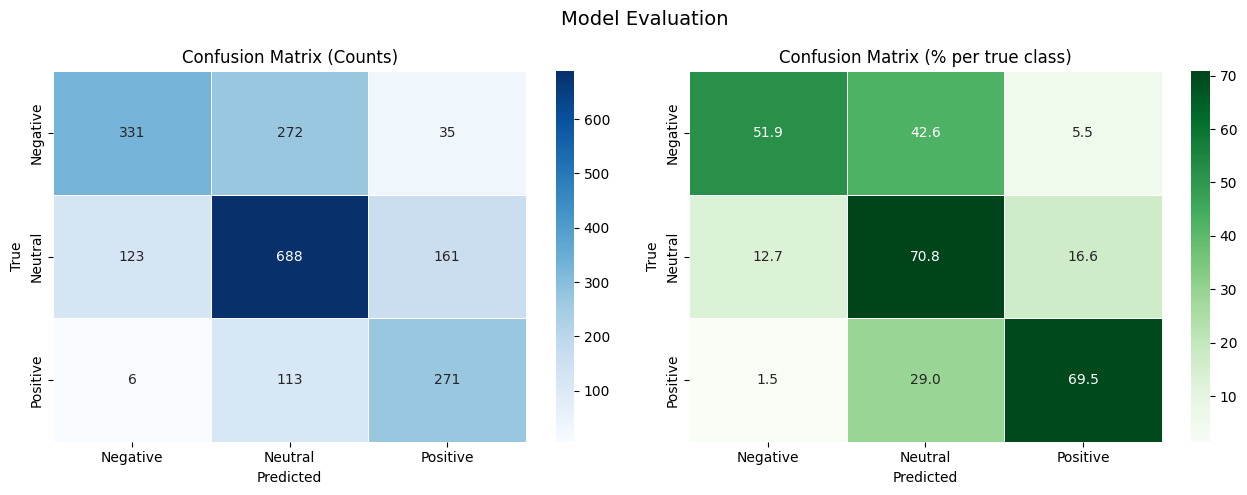

  Saved → confusion_matrix.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10: Comprehensive evaluation on test set
# Confusion matrix + per-class report + metrics
# ─────────────────────────────────────────────────────────────────────────────
print("📊 Evaluating on test set...")

# ── Get predictions ───────────────────────────────────────────────────────
predictions_output = trainer.predict(test_dataset)
logits   = predictions_output.predictions
y_true   = predictions_output.label_ids
y_pred   = np.argmax(logits, axis=1)
y_probs  = F.softmax(torch.tensor(logits), dim=1).numpy()

# ── Overall metrics ────────────────────────────────────────────────────────
acc    = accuracy_score(y_true, y_pred)
f1_w   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
f1_m   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
prec   = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec    = recall_score(y_true, y_pred,    average="weighted", zero_division=0)

print(f"\n{'='*50}")
print(f"  TEST SET RESULTS  ({TEST_SIZE} samples)")
print(f"{'='*50}")
print(f"  Accuracy          : {acc*100:.2f}%")
print(f"  F1-Score (weighted): {f1_w*100:.2f}%")
print(f"  F1-Score (macro)   : {f1_m*100:.2f}%")
print(f"  Precision          : {prec*100:.2f}%")
print(f"  Recall             : {rec*100:.2f}%")
print(f"{'='*50}")

# ── Classification report ──────────────────────────────────────────────────
print(f"\n  Per-class Classification Report:")
print(classification_report(y_true, y_pred,
                            target_names=LABEL_NAMES,
                            zero_division=0))

# ── Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Evaluation", fontsize=14)

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# Normalized (%)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Greens",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Confusion Matrix (% per true class)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("  Saved → confusion_matrix.png")

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11: Save model locally + test on custom text
# ─────────────────────────────────────────────────────────────────────────────

# ── Save model ─────────────────────────────────────────────────────────────
os.makedirs(SAVE_DIR, exist_ok=True)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"✅ Model saved → {SAVE_DIR}/")

# Verify saved files
print("  Saved files:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f"{SAVE_DIR}/{f}") / (1024*1024)
    print(f"    {f:<35} {size:.1f} MB")


# ── Prediction function ────────────────────────────────────────────────────
def predict_sentiment(text: str, verbose: bool = True) -> dict:
    """
    Predict sentiment for one text string.
    Returns: {"label": str, "confidence": float, "probabilities": dict}
    """
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors = "pt",
        truncation     = True,
        padding        = True,
        max_length     = MAX_LENGTH,
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    probs    = F.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    label    = LABEL_NAMES[pred_idx]
    emoji    = LABEL_EMOJIS[label]

    result = {
        "label"        : label,
        "emoji"        : emoji,
        "confidence"   : float(probs[pred_idx]),
        "probabilities": {LABEL_NAMES[i]: float(probs[i]) for i in range(NUM_LABELS)},
    }

    if verbose:
        print(f"  Input    : {text[:80]}")
        print(f"  Sentiment: {emoji} {label}  ({probs[pred_idx]*100:.1f}% confidence)")
        for lbl, prob in sorted(result["probabilities"].items(),
                                key=lambda x: -x[1]):
            bar = "█" * int(prob * 25)
            print(f"  {lbl:<10} {prob*100:5.1f}%  {bar}")
        print()

    return result


# ── Test on custom inputs ──────────────────────────────────────────────────
print("=" * 55)
print("  🧪 Custom Prediction Tests")
print("=" * 55)

test_texts = [
    "This product is absolutely amazing! Best purchase I ever made! 🎉",
    "The movie was okay, nothing special but not bad either.",
    "Terrible service! I waited 3 hours and they got my order wrong. Never coming back!",
    "Just another regular day at work...",
    "LOVE this! Highly recommend to everyone! 😍",
    "Not happy with the quality. Expected much better for the price.",
    "The weather is cloudy today.",
    "I can't believe how bad this experience was. Absolutely disgusting.",
]

for text in test_texts:
    predict_sentiment(text, verbose=True)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved → ./sentiment-model/
  Saved files:
    model.safetensors                   255.4 MB
    config.json                         0.0 MB
    tokenizer_config.json               0.0 MB
    tokenizer.json                      0.7 MB
  🧪 Custom Prediction Tests
  Input    : This product is absolutely amazing! Best purchase I ever made! 🎉
  Sentiment: 😊 Positive  (99.7% confidence)
  Positive    99.7%  ████████████████████████
  Negative     0.2%  
  Neutral      0.1%  

  Input    : The movie was okay, nothing special but not bad either.
  Sentiment: 😊 Positive  (99.5% confidence)
  Positive    99.5%  ████████████████████████
  Negative     0.3%  
  Neutral      0.2%  

  Input    : Terrible service! I waited 3 hours and they got my order wrong. Never coming bac
  Sentiment: 😠 Negative  (99.5% confidence)
  Negative    99.5%  ████████████████████████
  Neutral      0.3%  
  Positive     0.2%  

  Input    : Just another regular day at work...
  Sentiment: 😐 Neutral  (98.1% confid